# OpenCL Matrix Multiplication Benchmark (PyOpenCL)

This notebook benchmarks the original TP scripts **without modifying them**:

- `matmul_uncoalsced.py`
- `matmul_coalsced.py`
- `matmul_block.py`

All runs are launched via `subprocess`, `local_size` is passed through `stdin`, and performance lines are parsed with regex (`X seconds at Y MFLOPS`).

## 1) Device discovery

In [1]:
from pathlib import Path
import os
import re
import subprocess
import sys
from typing import Optional

import numpy as np
import pandas as pd
import pyopencl as cl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", None)

In [2]:
# Resolve project directories after re-organization
cwd = Path.cwd()
candidates = [
    cwd,
    cwd / "opencl_examples",
    cwd / "TP-CODESIGN" / "opencl_examples",
    cwd.parent,
]

OPENCL_DIR = None
for c in candidates:
    if (c / "prof_files" / "matmul_uncoalsced.py").exists():
        OPENCL_DIR = c
        break

if OPENCL_DIR is None:
    raise FileNotFoundError("Cannot locate opencl_examples/prof_files scripts.")

PROF_DIR = OPENCL_DIR / "prof_files"
BASE_DIR = OPENCL_DIR / "tp0_benchmark" if (OPENCL_DIR / "tp0_benchmark").exists() else OPENCL_DIR

print(f"Using OPENCL_DIR = {OPENCL_DIR}")
print(f"Using PROF_DIR   = {PROF_DIR}")
print(f"Using BASE_DIR   = {BASE_DIR}")


Using BASE_DIR = c:\Users\medte\OneDrive\Desktop\Codesign_tp\TP-CODESIGN\opencl_examples


In [3]:
def discover_opencl_devices() -> pd.DataFrame:
    rows = []
    for p_idx, platform in enumerate(cl.get_platforms()):
        for d_idx, device in enumerate(platform.get_devices()):
            rows.append(
                {
                    "platform_index": p_idx,
                    "device_index": d_idx,
                    "platform_name": platform.name.strip(),
                    "device_name": device.name.strip(),
                    "device_vendor": device.vendor.strip(),
                    "device_type": cl.device_type.to_string(device.type),
                    "compute_units": int(device.max_compute_units),
                    "global_mem_size (GB)": round(device.global_mem_size / (1024**3), 3),
                    "local_mem_size (KB)": round(device.local_mem_size / 1024, 1),
                    "max_work_group_size": int(device.max_work_group_size),
                    "max_work_item_sizes": tuple(int(x) for x in device.max_work_item_sizes),
                }
            )
    return pd.DataFrame(rows)


def classify_tp_device(row: pd.Series) -> Optional[str]:
    name = f"{row['device_name']} {row['device_vendor']}".lower()
    dtype = str(row["device_type"]).upper()

    if "CPU" in dtype:
        return "CPU"
    if "GPU" in dtype and "nvidia" in name:
        return "NVIDIA GPU"
    if "GPU" in dtype and ("intel" in name or "integrated" in name):
        return "Intel GPU"
    return None


devices_df = discover_opencl_devices()
devices_df["tp_device"] = devices_df.apply(classify_tp_device, axis=1)
devices_df

,platform_index,device_index,platform_name,device_name,device_vendor,device_type,compute_units,global_mem_size (GB),local_mem_size (KB),max_work_group_size,max_work_item_sizes,tp_device
0,0,0,NVIDIA CUDA,NVIDIA GeForce RTX 3050 6GB Laptop GPU,NVIDIA Corporation,ALL | GPU,20,6.000,48.0,1024,"(1024, 1024, 64)",NVIDIA GPU
1,1,0,Intel(R) OpenCL Graphics,Intel(R) UHD Graphics,Intel(R) Corporation,ALL | GPU,64,10.675,64.0,512,"(512, 512, 512)",Intel GPU
2,2,0,Intel(R) OpenCL,13th Gen Intel(R) Core(TM) i7-13620H,Intel(R) Corporation,ALL | CPU,16,23.649,256.0,8192,"(8192, 8192, 8192)",CPU


In [5]:
def select_tp_devices(devices: pd.DataFrame) -> pd.DataFrame:
    wanted = ["CPU", "Intel GPU", "NVIDIA GPU"]
    picks = []

    for label in wanted:
        sub = devices[devices["tp_device"] == label]
        if len(sub) == 0:
            picks.append(
                {
                    "tp_device": label,
                    "platform_index": np.nan,
                    "device_index": np.nan,
                    "device_name": "NOT FOUND",
                    "device_type": "",
                    "PYOPENCL_CTX": None,
                }
            )
        else:
            row = sub.iloc[0]
            picks.append(
                {
                    "tp_device": label,
                    "platform_index": int(row["platform_index"]),
                    "device_index": int(row["device_index"]),
                    "device_name": row["device_name"],
                    "device_type": row["device_type"],
                    "PYOPENCL_CTX": f"{int(row['platform_index'])}:{int(row['device_index'])}",
                }
            )

    return pd.DataFrame(picks)


selected_devices = select_tp_devices(devices_df)
selected_devices


,tp_device,platform_index,device_index,device_name,device_type,PYOPENCL_CTX
0,CPU,2,0,13th Gen Intel(R) Core(TM) i7-13620H,ALL | CPU,2:0
1,Intel GPU,1,0,Intel(R) UHD Graphics,ALL | GPU,1:0
2,NVIDIA GPU,0,0,NVIDIA GeForce RTX 3050 6GB Laptop GPU,ALL | GPU,0:0


## 2) Benchmark execution

In [6]:
# TP configuration (exact values)
N_VALUES = [2048, 4096, 8192]
LOCAL_SIZES = [4, 8, 16, 32]
REPEATS = 2

# Execution policy for this phase:
# - Continue benchmark on NVIDIA only
# - Keep already collected results from previous runs (CPU/Intel/NVIDIA)
RUN_DEVICE_FILTER = ["NVIDIA GPU"]

# Visualization/report focus for this submission pass
PLOT_DEVICE_ORDER = ["CPU", "NVIDIA GPU"]
INTEL_GPU_NOTE = "Intel integrated GPU runs were stopped early due to execution time constraints."

SCRIPTS = {
    "uncoalesced": PROF_DIR / "matmul_uncoalsced.py",
    "coalesced": PROF_DIR / "matmul_coalsced.py",
    "block": PROF_DIR / "matmul_block.py",
}

for k, p in SCRIPTS.items():
    if not p.exists():
        raise FileNotFoundError(f"Missing script: {p}")

PERF_REGEX = re.compile(
    r"([0-9]*\.?[0-9]+(?:[eE][-+]?\d+)?)\s+seconds\s+at\s+([0-9]*\.?[0-9]+(?:[eE][-+]?\d+)?)\s+MFLOPS"
)


In [7]:
def make_runtime_variant(script_path: Path, n_value: int) -> Path:
    """
    Create a temporary runtime copy with only N changed.
    Original TP script remains unchanged.
    """
    variant_path = script_path.with_name(f"{script_path.stem}_N{n_value}_runtime.py")
    if variant_path.exists():
        return variant_path

    text = script_path.read_text(encoding="utf-8")
    updated, count = re.subn(r"(?m)^N\s*=\s*\d+\s*;?\s*$", f"N = {n_value}", text, count=1)
    if count != 1:
        raise RuntimeError(f"Could not patch N in {script_path.name}")

    variant_path.write_text(updated, encoding="utf-8")
    return variant_path


def run_one_script(
    script_path: Path,
    kernel: str,
    device_label: str,
    pyopencl_ctx: str,
    n_value: int,
    local_size: int,
    run_id: int,
    timeout_sec: int = 3600,
) -> dict:
    runtime_script = make_runtime_variant(script_path, n_value)

    env = os.environ.copy()
    env["PYOPENCL_CTX"] = pyopencl_ctx

    proc = subprocess.run(
        [sys.executable, str(runtime_script.name)],
        input=f"{local_size}\n",
        text=True,
        capture_output=True,
        cwd=str(script_path.parent),
        env=env,
        timeout=timeout_sec,
    )

    output = (proc.stdout or "") + "\n" + (proc.stderr or "")
    matches = PERF_REGEX.findall(output)

    if proc.returncode != 0 or not matches:
        return {
            "device_label": device_label,
            "kernel": kernel,
            "script": script_path.name,
            "N": n_value,
            "local_size": local_size,
            "run_id": run_id,
            "seconds": np.nan,
            "mflops": np.nan,
            "success": False,
            "returncode": proc.returncode,
            "stdout_tail": output[-1200:],
        }

    sec_str, mflops_str = matches[-1]
    return {
        "device_label": device_label,
        "kernel": kernel,
        "script": script_path.name,
        "N": n_value,
        "local_size": local_size,
        "run_id": run_id,
        "seconds": float(sec_str),
        "mflops": float(mflops_str),
        "success": True,
        "returncode": proc.returncode,
        "stdout_tail": output[-1200:],
    }

In [8]:
def run_full_campaign(
    selected_devices_df: pd.DataFrame,
    scripts: dict,
    n_values: list[int],
    local_sizes: list[int],
    repeats: int = 2,
    autosave_path: Optional[Path] = None,
    autosave_every: int = 1,
    resume_from_checkpoint: bool = True,
    skip_existing: bool = True,
) -> pd.DataFrame:
    if autosave_path is None:
        autosave_path = BASE_DIR / "tp0_matmul_raw_results_checkpoint.csv"
    autosave_path = Path(autosave_path)
    summary_checkpoint_path = autosave_path.with_name(autosave_path.stem + "_summary.csv")

    rows = []
    if resume_from_checkpoint and autosave_path.exists():
        prev = pd.read_csv(autosave_path)
        if len(prev) > 0:
            rows = prev.to_dict(orient="records")
            print(f"Loaded existing checkpoint rows: {len(rows)} from {autosave_path}")

    runnable = selected_devices_df[selected_devices_df["PYOPENCL_CTX"].notna()].copy()
    if runnable.empty:
        raise RuntimeError("No runnable TP devices found for the current RUN_DEVICE_FILTER.")

    tasks = []
    for _, dev in runnable.iterrows():
        for kernel, script_path in scripts.items():
            for n_value in n_values:
                for lsize in local_sizes:
                    for run_id in range(1, repeats + 1):
                        tasks.append(
                            {
                                "device_label": dev["tp_device"],
                                "pyopencl_ctx": dev["PYOPENCL_CTX"],
                                "kernel": kernel,
                                "script_path": script_path,
                                "N": n_value,
                                "local_size": lsize,
                                "run_id": run_id,
                            }
                        )

    total = len(tasks)

    existing_keys = set()
    for r in rows:
        try:
            key = (
                str(r["device_label"]),
                str(r["kernel"]),
                int(r["N"]),
                int(r["local_size"]),
                int(r["run_id"]),
            )
            existing_keys.add(key)
        except Exception:
            continue

    def save_checkpoint() -> None:
        if len(rows) == 0:
            return

        df = pd.DataFrame(rows)
        df.to_csv(autosave_path, index=False)

        success_mask = df["success"].astype(str).str.lower().eq("true")
        ok = df[success_mask].copy()
        if len(ok) > 0:
            summary_ckpt = (
                ok.groupby(["device_label", "kernel", "N", "local_size"], as_index=False)
                .agg(
                    mean_mflops=("mflops", "mean"),
                    std_mflops=("mflops", "std"),
                    runs=("mflops", "count"),
                )
                .sort_values(["kernel", "N", "device_label", "local_size"])
            )
            summary_ckpt.to_csv(summary_checkpoint_path, index=False)

    try:
        for idx, t in enumerate(tasks, start=1):
            key = (t["device_label"], t["kernel"], t["N"], t["local_size"], t["run_id"])

            if skip_existing and key in existing_keys:
                print(
                    f"[{idx}/{total}] {t['device_label']} | {t['kernel']} | N={t['N']} | local={t['local_size']} | run={t['run_id']} | SKIP(existing)",
                    flush=True,
                )
                continue

            print(
                f"[{idx}/{total}] {t['device_label']} | {t['kernel']} | N={t['N']} | local={t['local_size']} | run={t['run_id']}",
                flush=True,
            )

            rows.append(
                run_one_script(
                    script_path=t["script_path"],
                    kernel=t["kernel"],
                    device_label=t["device_label"],
                    pyopencl_ctx=t["pyopencl_ctx"],
                    n_value=t["N"],
                    local_size=t["local_size"],
                    run_id=t["run_id"],
                )
            )
            existing_keys.add(key)

            if autosave_every > 0 and (idx % autosave_every == 0):
                save_checkpoint()

    except KeyboardInterrupt:
        print("\nInterrupted by user. Saving checkpoint before exit...", flush=True)
        save_checkpoint()
        print(f"Checkpoint saved: {autosave_path}", flush=True)
        print(f"Summary checkpoint saved: {summary_checkpoint_path}", flush=True)
        raise

    save_checkpoint()
    print(f"Checkpoint saved: {autosave_path}", flush=True)
    print(f"Summary checkpoint saved: {summary_checkpoint_path}", flush=True)

    return pd.DataFrame(rows)


In [9]:
# This is the main benchmark execution cell.
# It can be long for N=8192 depending on hardware.
checkpoint_csv = BASE_DIR / "tp0_matmul_raw_results_checkpoint.csv"

run_devices = selected_devices[
    selected_devices["tp_device"].isin(RUN_DEVICE_FILTER)
].reset_index(drop=True)

print("Run devices:")
display(run_devices)

raw_results = run_full_campaign(
    selected_devices_df=run_devices,
    scripts=SCRIPTS,
    n_values=N_VALUES,
    local_sizes=LOCAL_SIZES,
    repeats=REPEATS,
    autosave_path=checkpoint_csv,
    autosave_every=1,
    resume_from_checkpoint=True,
    skip_existing=True,
)

raw_results.head()


Run devices:


,tp_device,platform_index,device_index,device_name,device_type,PYOPENCL_CTX
0,NVIDIA GPU,0,0,NVIDIA GeForce RTX 3050 6GB Laptop GPU,ALL | GPU,0:0


Loaded existing checkpoint rows: 17 from c:\Users\medte\OneDrive\Desktop\Codesign_tp\TP-CODESIGN\opencl_examples\tp0_matmul_raw_results_checkpoint.csv
[1/72] NVIDIA GPU | uncoalesced | N=2048 | local=4 | run=1
[2/72] NVIDIA GPU | uncoalesced | N=2048 | local=4 | run=2
[3/72] NVIDIA GPU | uncoalesced | N=2048 | local=8 | run=1
[4/72] NVIDIA GPU | uncoalesced | N=2048 | local=8 | run=2
[5/72] NVIDIA GPU | uncoalesced | N=2048 | local=16 | run=1
[6/72] NVIDIA GPU | uncoalesced | N=2048 | local=16 | run=2
[7/72] NVIDIA GPU | uncoalesced | N=2048 | local=32 | run=1
[8/72] NVIDIA GPU | uncoalesced | N=2048 | local=32 | run=2
[9/72] NVIDIA GPU | uncoalesced | N=4096 | local=4 | run=1
[10/72] NVIDIA GPU | uncoalesced | N=4096 | local=4 | run=2
[11/72] NVIDIA GPU | uncoalesced | N=4096 | local=8 | run=1
[12/72] NVIDIA GPU | uncoalesced | N=4096 | local=8 | run=2
[13/72] NVIDIA GPU | uncoalesced | N=4096 | local=16 | run=1
[14/72] NVIDIA GPU | uncoalesced | N=4096 | local=16 | run=2
[15/72] NVID

,device_label,kernel,script,N,local_size,run_id,seconds,mflops,success,returncode,stdout_tail
0,Intel GPU,uncoalesced,matmul_uncoalsced.py,2048,4,1,11.833583,29035.785721,True,0,"Matrix multiplication 2048 * 2048 repeated 20 times, i=0, j=1 :\n\nPlease enter a value for localsize. Possible values: 4, 8, 16 and 32 :\nBlocks Size is 4 * 4 \n\n\n Starting 20 OpenCL Matrix Multiplications\n\n End of 20 Matrix Multiplications\n\n11.833583116531372 seconds at 29035.785720725504 MFLOPS\n\nc:\Users\medte\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyopencl\cache.py:496: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.\n _create_built_program_from_source_cached(\n"
1,Intel GPU,uncoalesced,matmul_uncoalsced.py,2048,4,2,11.927636,28806.830316,True,0,"Matrix multiplication 2048 * 2048 repeated 20 times, i=0, j=1 :\n\nPlease enter a value for localsize. Possible values: 4, 8, 16 and 32 :\nBlocks Size is 4 * 4 \n\n\n Starting 20 OpenCL Matrix Multiplications\n\n End of 20 Matrix Multiplications\n\n11.927635908126831 seconds at 28806.83031629862 MFLOPS\n\nc:\Users\medte\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyopencl\cache.py:496: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.\n _create_built_program_from_source_cached(\n"
2,Intel GPU,uncoalesced,matmul_uncoalsced.py,2048,8,1,18.433480,18639.854397,True,0,"Matrix multiplication 2048 * 2048 repeated 20 times, i=0, j=1 :\n\nPlease enter a value for localsize. Possible values: 4, 8, 16 and 32 :\nBlocks Size is 8 * 8 \n\n\n Starting 20 OpenCL Matrix Multiplications\n\n End of 20 Matrix Multiplications\n\n18.43348002433777 seconds at 18639.85439680123 MFLOPS\n\nc:\Users\medte\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyopencl\cache.py:496: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.\n _create_built_program_from_source_cached(\n"
3,Intel GPU,uncoalesced,matmul_uncoalsced.py,2048,8,2,19.311482,17792.388203,True,0,"Matrix multiplication 2048 * 2048 repeated 20 times, i=0, j=1 :\n\nPlease enter a value for localsize. Possible values: 4, 8, 16 and 32 :\nBlocks Size is 8 * 8 \n\n\n Starting 20 OpenCL Matrix Multiplications\n\n End of 20 Matrix Multiplications\n\n19.311481952667236 seconds at 17792.388203151 MFLOPS\n\nc:\Users\medte\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyopencl\cache.py:496: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.\n _create_built_program_from_source_cached(\n"
4,Intel GPU,uncoalesced,matmul_uncoalsced.py,2048,16,1,35.964682,9553.744623,True,0,"Matrix multiplication 2048 * 2048 repeated 20 times, i=0, j=1 :\n\nPlease enter a value for localsize. Possible values: 4, 8, 16 and 32 :\nBlocks Size is 16 * 16 \n\n\n Starting 20 OpenCL Matrix Multiplications\n\n End of 20 Matrix Multiplications\n\n35.96468162536621 seconds at 9553.744622548185 MFLOPS\n\nc:\Users\medte\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyopencl\cache.py:496: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.\n _create_built_program_from_source_cached(\n"


In [10]:
success_mask = raw_results["success"].astype(str).str.lower().eq("true")
summary = (
    raw_results[success_mask]
    .groupby(["device_label", "kernel", "N", "local_size"], as_index=False)
    .agg(
        mean_mflops=("mflops", "mean"),
        std_mflops=("mflops", "std"),
        runs=("mflops", "count"),
    )
    .sort_values(["kernel", "N", "device_label", "local_size"])
)

summary


,device_label,kernel,N,local_size,mean_mflops,std_mflops,runs
9,NVIDIA GPU,block,2048,8,4.473448e+05,6.018947e+01,2
10,NVIDIA GPU,block,2048,16,4.650987e+05,1.543219e+03,2
11,NVIDIA GPU,block,2048,32,3.755379e+05,1.305042e+02,2
12,NVIDIA GPU,block,4096,8,4.750385e+05,1.031373e+02,2
13,NVIDIA GPU,block,4096,16,5.049372e+05,2.957873e+03,2
14,NVIDIA GPU,block,4096,32,4.093889e+05,4.658100e+02,2
15,NVIDIA GPU,block,8192,8,4.608740e+05,3.415818e+02,2
16,NVIDIA GPU,block,8192,16,5.097540e+05,3.521040e+02,2
17,NVIDIA GPU,block,8192,32,4.100574e+05,1.657284e+03,2
18,NVIDIA GPU,coalesced,2048,4,1.652264e+05,1.282507e+03,2


## 3) Tables (required by TP)

In [11]:
print(f"Note: {INTEL_GPU_NOTE}")

available_devices = list(summary["device_label"].dropna().unique())
DEVICE_ORDER = [d for d in PLOT_DEVICE_ORDER if d in available_devices]
if len(DEVICE_ORDER) == 0:
    DEVICE_ORDER = sorted(available_devices)

COL_ORDER = [4, 8, 16, 32]
KERNEL_ORDER = ["uncoalesced", "coalesced", "block"]


def make_tp_table(summary_df: pd.DataFrame, kernel: str, n_value: int) -> pd.DataFrame:
    sub = summary_df[
        (summary_df["kernel"] == kernel) &
        (summary_df["N"] == n_value) &
        (summary_df["device_label"].isin(DEVICE_ORDER))
    ]
    pivot = sub.pivot(index="device_label", columns="local_size", values="mean_mflops")
    pivot = pivot.reindex(index=DEVICE_ORDER, columns=COL_ORDER)
    pivot.columns = [f"{c}x{c}" for c in pivot.columns]
    return pivot


for kernel in KERNEL_ORDER:
    print(f"\n===== Kernel: {kernel} =====")
    for n_value in N_VALUES:
        print(f"\nN = {n_value}")
        display(make_tp_table(summary, kernel, n_value).round(2))


Note: Intel integrated GPU runs were stopped early due to execution time constraints.

===== Kernel: uncoalesced =====

N = 2048


,4x4,8x8,16x16,32x32
device_label,,,,
NVIDIA GPU,111991.52,258160.57,140653.83,74019.02



N = 4096


,4x4,8x8,16x16,32x32
device_label,,,,
NVIDIA GPU,113060.69,254495.86,135563.82,73429.0



N = 8192


...

,4x4,8x8,16x16,32x32
device_label,,,,
NVIDIA GPU,NaN,447344.79,465098.66,375537.93



N = 4096


,4x4,8x8,16x16,32x32
device_label,,,,
NVIDIA GPU,NaN,475038.46,504937.19,409388.94



N = 8192


,4x4,8x8,16x16,32x32
device_label,,,,
NVIDIA GPU,NaN,460874.01,509754.02,410057.39


## 4) Visualizations

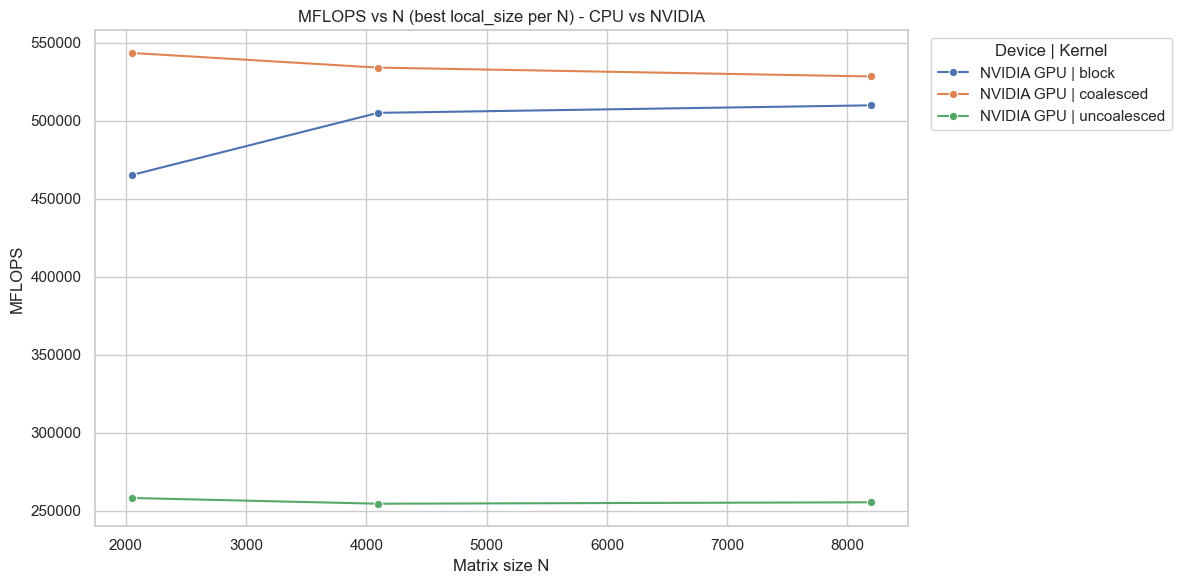

In [12]:
# A) Line plot: X=N, Y=MFLOPS, curves for each (device, kernel)
plot_summary = summary[summary["device_label"].isin(PLOT_DEVICE_ORDER)].copy()

if plot_summary.empty:
    print("No data available yet for selected plot devices.")
else:
    line_df = plot_summary.loc[
        plot_summary.groupby(["device_label", "kernel", "N"]) ["mean_mflops"].idxmax()
    ].copy()
    line_df["curve"] = line_df["device_label"] + " | " + line_df["kernel"]

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=line_df,
        x="N",
        y="mean_mflops",
        hue="curve",
        marker="o",
    )
    plt.title("MFLOPS vs N (best local_size per N) - CPU vs NVIDIA")
    plt.xlabel("Matrix size N")
    plt.ylabel("MFLOPS")
    plt.legend(title="Device | Kernel", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


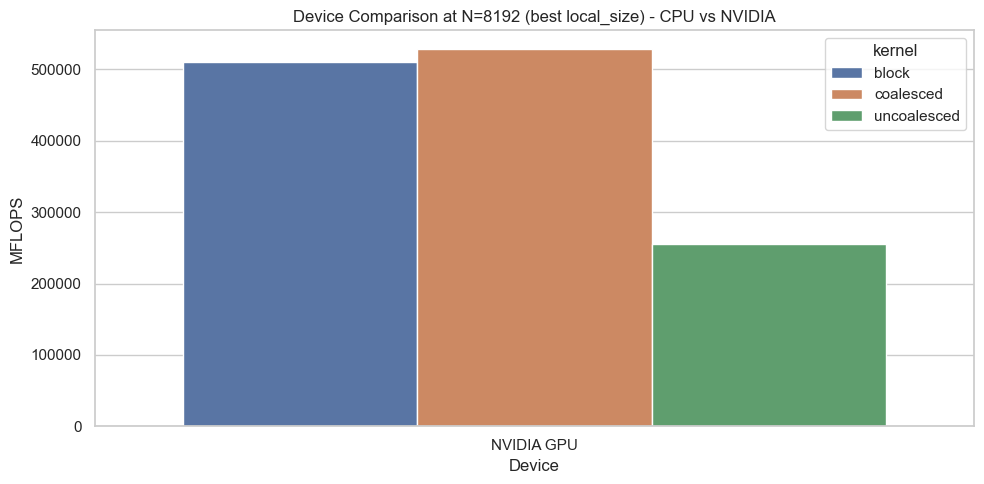

In [13]:
# B) Bar plot: device comparison for N=8192, 3 kernels side-by-side
plot_summary = summary[summary["device_label"].isin(PLOT_DEVICE_ORDER)].copy()
bar_df = plot_summary[plot_summary["N"] == 8192].copy()

if bar_df.empty:
    print("No N=8192 data available yet for selected plot devices.")
else:
    bar_df = bar_df.loc[bar_df.groupby(["device_label", "kernel"]) ["mean_mflops"].idxmax()]

    plt.figure(figsize=(10, 5))
    sns.barplot(data=bar_df, x="device_label", y="mean_mflops", hue="kernel")
    plt.title("Device Comparison at N=8192 (best local_size) - CPU vs NVIDIA")
    plt.xlabel("Device")
    plt.ylabel("MFLOPS")
    plt.tight_layout()
    plt.show()


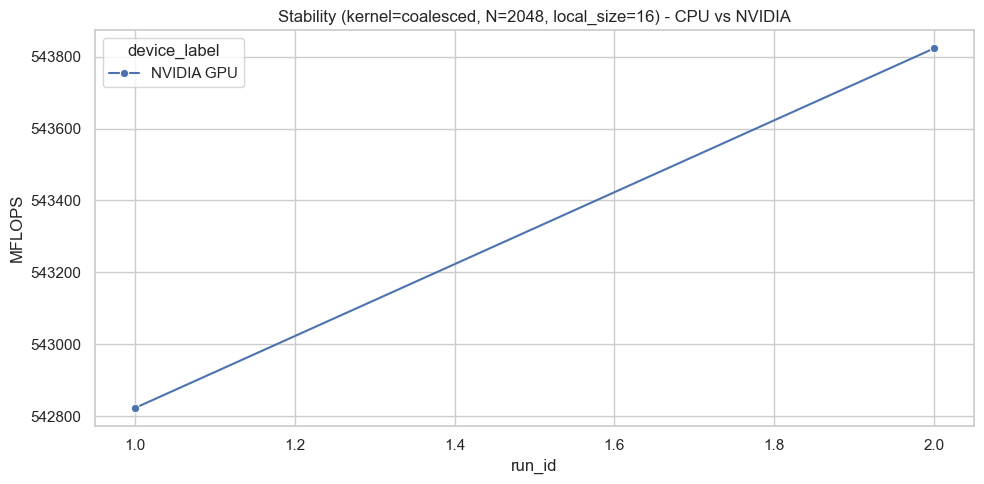

In [14]:
# C) Stability plot: N=2048, local_size=16, kernel=coalesced
success_mask = raw_results["success"].astype(str).str.lower().eq("true")
stab_df = raw_results[
    success_mask &
    (raw_results["kernel"] == "coalesced") &
    (raw_results["N"] == 2048) &
    (raw_results["local_size"] == 16) &
    (raw_results["device_label"].isin(PLOT_DEVICE_ORDER))
].copy()

if stab_df.empty:
    print("No stability data available yet for (coalesced, N=2048, local_size=16).")
else:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=stab_df, x="run_id", y="mflops", hue="device_label", marker="o")
    plt.title("Stability (kernel=coalesced, N=2048, local_size=16) - CPU vs NVIDIA")
    plt.xlabel("run_id")
    plt.ylabel("MFLOPS")
    plt.tight_layout()
    plt.show()


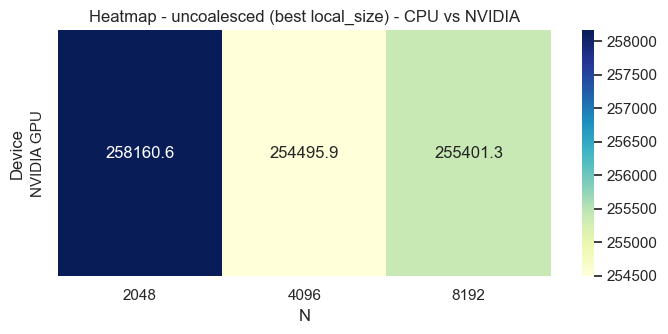

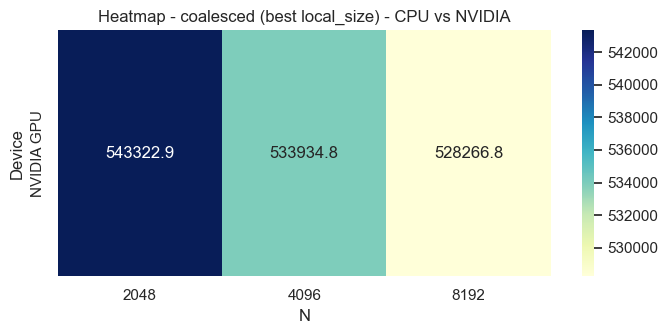

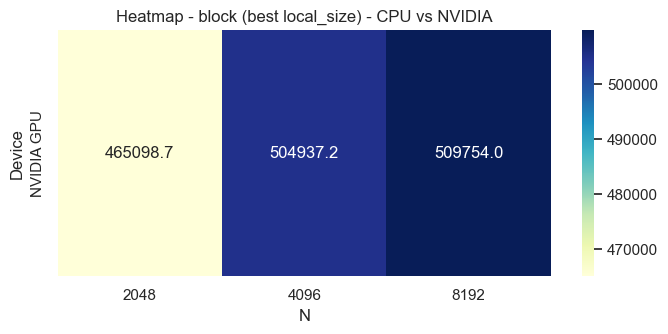

In [15]:
# D) Heatmaps: device vs N, one heatmap per kernel
plot_summary = summary[summary["device_label"].isin(PLOT_DEVICE_ORDER)].copy()

if plot_summary.empty:
    print("No heatmap data available yet for selected plot devices.")
else:
    heatmap_src = plot_summary.loc[
        plot_summary.groupby(["kernel", "device_label", "N"]) ["mean_mflops"].idxmax()
    ]

    for kernel in KERNEL_ORDER:
        pivot = (
            heatmap_src[heatmap_src["kernel"] == kernel]
            .pivot(index="device_label", columns="N", values="mean_mflops")
            .reindex(index=DEVICE_ORDER, columns=N_VALUES)
        )

        plt.figure(figsize=(7, 3.5))
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
        plt.title(f"Heatmap - {kernel} (best local_size) - CPU vs NVIDIA")
        plt.xlabel("N")
        plt.ylabel("Device")
        plt.tight_layout()
        plt.show()


## 5) CSV export

In [16]:
raw_csv = BASE_DIR / "tp0_matmul_raw_results.csv"
summary_csv = BASE_DIR / "tp0_matmul_summary_results.csv"

raw_results.to_csv(raw_csv, index=False)
summary.to_csv(summary_csv, index=False)

print(f"Saved: {raw_csv}")
print(f"Saved: {summary_csv}")

Saved: c:\Users\medte\OneDrive\Desktop\Codesign_tp\TP-CODESIGN\opencl_examples\tp0_matmul_raw_results.csv
Saved: c:\Users\medte\OneDrive\Desktop\Codesign_tp\TP-CODESIGN\opencl_examples\tp0_matmul_summary_results.csv
